<a href="https://colab.research.google.com/github/neelsoumya/visualization_lecture/blob/main/Data_Visualisation_week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Goal:**

Use the 3 principals of good visualisation to improve the following tasks ->

**Exercise 1: Sales Data Analysis**

**Objective**: Analyze sales data to identify trends, seasonality, and outliers.

**Data**: Monthly sales data for a retail company over five years, including change in sales value.

**Tasks**:

Plot monthly sales over the five-year period to visualize trends and seasonality.
Create a box plot to identify any outliers in monthly sales data.

**Data Access**:
For this exercise, you can use the "Monthly State Retail Sales" (*Not Adjusted State Retail Sales Year-over-Year Percentage Changes* called as "state_retail_yy.csv") data from the U.S. Census Bureau. This data includes state-level retail sales figures, starting from January 2019, and covers various retail sectors. It's a comprehensive dataset that can be used to analyze trends, seasonality, and outliers in retail sales across different states and sectors. The data is updated regularly and available in CSV format, which is convenient for analysis in Python using libraries like Pandas and Matplotlib.

Link to data set: https://www.census.gov/retail/state_retail_sales.html

Note: 'naics' in the data stands for North American Industry Classification System (naics)

- Matplotlib Documentation can be accessed from here: https://matplotlib.org/stable/index.html
- Seaborn Documentaion can be accessed from here: https://seaborn.pydata.org/

* Download the csv file `state_retail_yy.csv`
* In your Google Drive `My Drive`, create a folder named `YSJ-DataVis`
* Save the file `state_retail_yy.csv` in that folder

In [34]:
# Step 1: Mount Google Drive
# This will prompt for authorization to access your drive.
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import necessary libraries
import pandas as pd

# Make sure to replace 'your_path_here' with the actual path to the CSV file in your Google Drive
file_path = '/content/drive/My Drive/YSJ-DataVis/state_retail_yy.csv'

# Reading the data from the CSV file into a pandas DataFrame.
df = pd.read_csv(file_path)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   fips stateabbr naics yy201901 yy201902 yy201903  yy201904 yy201905  \
0     0       USA   441     -0.1      0.3      0.7       4.1      2.4   
1     0       USA   442     -0.4     -0.5     -1.4       2.6      2.2   
2     0       USA   443     -0.7     -4.8     -4.3      -4.2     -2.9   
3     0       USA   444     13.3      2.3      0.6       6.2     -1.9   
4     0       USA   445      4.6      1.3      0.2       5.4      3.7   

  yy201906 yy201907  ... yy202412 yy202501 yy202502 yy202503 yy202504  \
0     -0.2      5.2  ...      7.4      5.8     -1.6     10.3      8.3   
1     -1.3      2.9  ...      8.4      6.9      3.0      6.9      8.0   
2     -6.1     -2.1  ...      5.1     -3.0     -7.0      1.8     -0.4   
3     -4.3      1.4  ...      1.3      1.0     -6.1      3.5      1.2   
4      3.2      5.1  ...      1.5      5.0      0.3      0.7      5

# Data cleaning and plotting

* `monthly_sales_columns = [col for col in df if col.startswith('yy')]`: This creates a list of column names from the DataFrame df that start with 'yy'. These columns are assumed to contain the monthly sales data.
* `df[monthly_sales_columns] = df[monthly_sales_columns].apply(pd.to_numeric, errors='coerce').fillna(0)`: This is a data cleaning step. It takes all the columns identified as monthly_sales_columns and attempts to convert their values to a numeric type.
* If a value cannot be converted (e.g., it's not a number), errors='coerce' will replace it with NaN (Not a Number). After this, fillna(0) replaces all NaN values with 0, ensuring all sales data is numeric.
* `monthly_sales = df[monthly_sales_columns].sum()`: This line calculates the sum of sales for each month across all entries in the DataFrame. The result is a pandas Series where the index represents the months and the values are the total sales for that month.

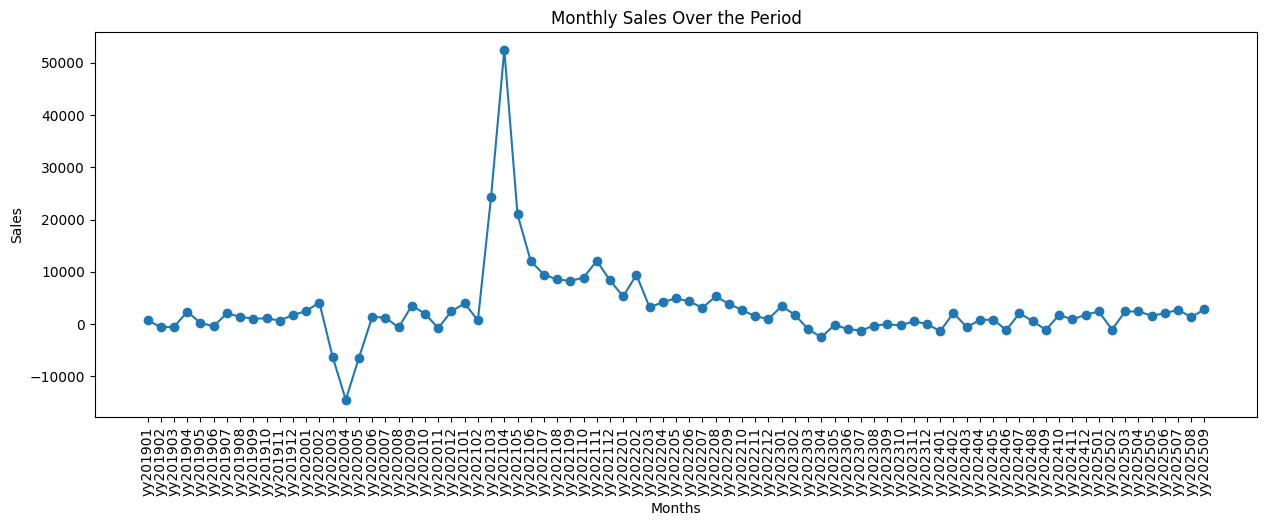

In [35]:
import matplotlib.pyplot as plt

# Convert all monthly sales data to numeric, forcing non-numeric to NaN, then fill with 0
monthly_sales_columns = [col for col in df if col.startswith('yy')]
df[monthly_sales_columns] = df[monthly_sales_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# Now sum the sales for each month
monthly_sales = df[monthly_sales_columns].sum()

# Plot the monthly sales
plt.figure(figsize=(15, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title('Monthly Sales Over the Period')
plt.ylabel('Sales')
plt.xlabel('Months')
plt.xticks(rotation=90)
plt.show()

# 🎮💡🛠️ Activity

Lets come up with some nice time series visualizations with some themes (xkcd, star wars, lord of the rings, etc.)!

# Boxplot

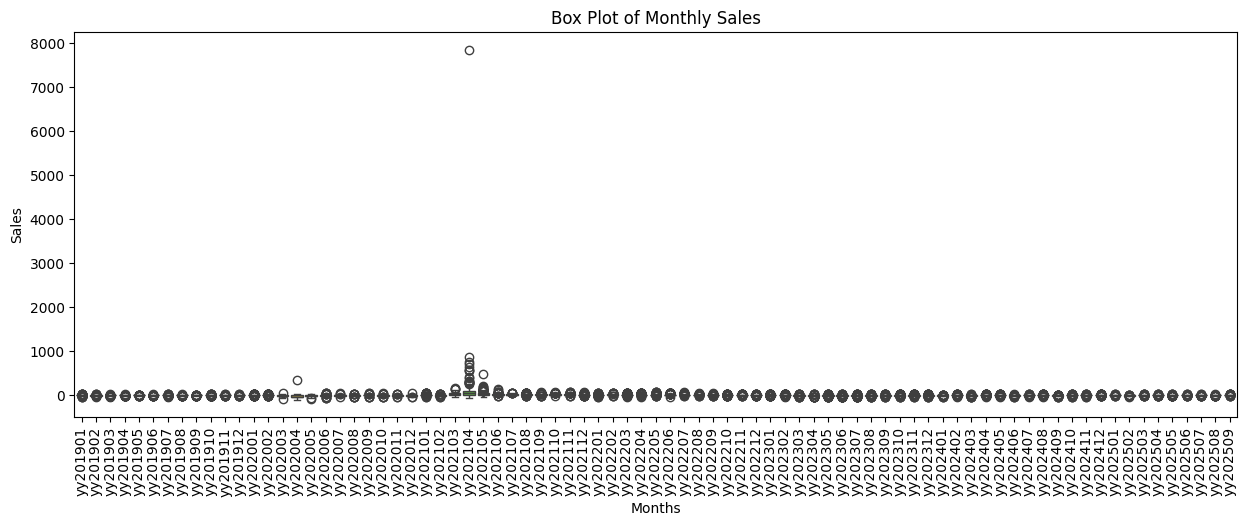

In [36]:
import seaborn as sns

# The same monthly_sales_columns are used here
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[monthly_sales_columns])
plt.title('Box Plot of Monthly Sales')
plt.ylabel('Sales')
plt.xlabel('Months')
plt.xticks(rotation=90)
plt.show()

# Question

* Does the above plot look weird? Why?


**Exercise 2: Time Series Analysis of Stock Prices**



# Generate synthetic data

In [37]:
import numpy as np
import pandas as pd

# For reproducibility
np.random.seed(42)

# Generate business days for 2 years
dates = pd.bdate_range(start="2023-01-01", end="2024-12-31")

n = len(dates)

# Simulate daily returns
trend = 0.0005                # upward drift
volatility = 0.01             # normal daily noise
returns = np.random.normal(trend, volatility, n)

# Add a few random market shocks
shock_days = np.random.choice(n, size=10, replace=False)
returns[shock_days] += np.random.normal(0, 0.05, size=10)

# Generate price series using cumulative returns
price = 100 * np.exp(np.cumsum(returns))

# Create dataframe
df = pd.DataFrame({
    "Date": dates,
    "Close": price
})

df.set_index("Date", inplace=True)

df.head()


,Close
Date,
2023-01-02,100.548211
2023-01-03,100.459502
2023-01-04,101.162848
2023-01-05,102.766751
2023-01-06,102.577677


# Calculate moving averages

In [38]:
# Moving averages
df["MA30"] = df["Close"].rolling(window=30).mean()
df["MA90"] = df["Close"].rolling(window=90).mean()

df.head()


,Close,MA30,MA90
Date,,,
2023-01-02,100.548211,NaN,NaN
2023-01-03,100.459502,NaN,NaN
2023-01-04,101.162848,NaN,NaN
2023-01-05,102.766751,NaN,NaN
2023-01-06,102.577677,NaN,NaN


# Visualize the time series

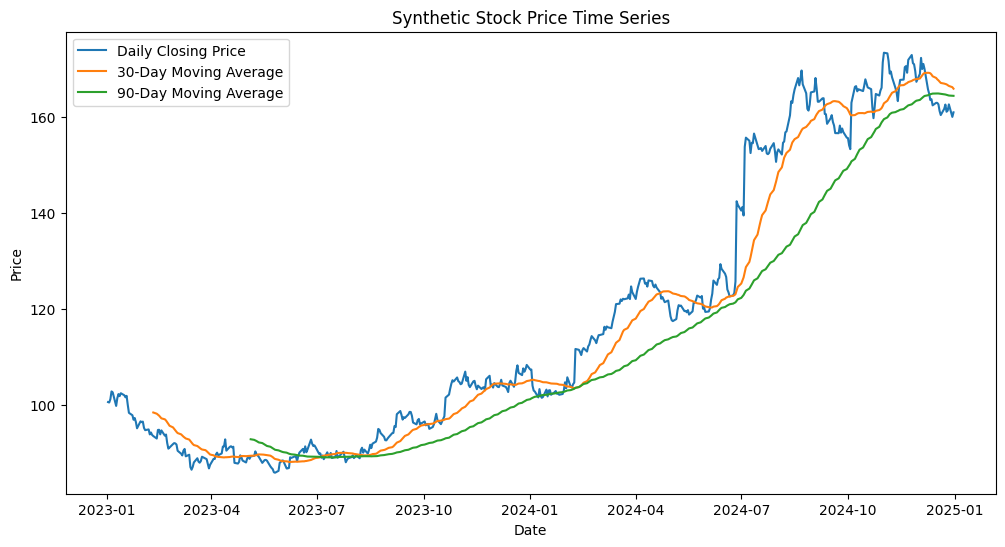

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Daily Closing Price")
plt.plot(df.index, df["MA30"], label="30-Day Moving Average")
plt.plot(df.index, df["MA90"], label="90-Day Moving Average")

plt.title("Synthetic Stock Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()


# Compare multiple stocks

In [40]:
df["Stock_B"] = df["Close"] * np.exp(np.cumsum(np.random.normal(0.0003,0.012,n)))
df["Stock_C"] = df["Close"] * np.exp(np.cumsum(np.random.normal(-0.0001,0.02,n)))


# Volatility

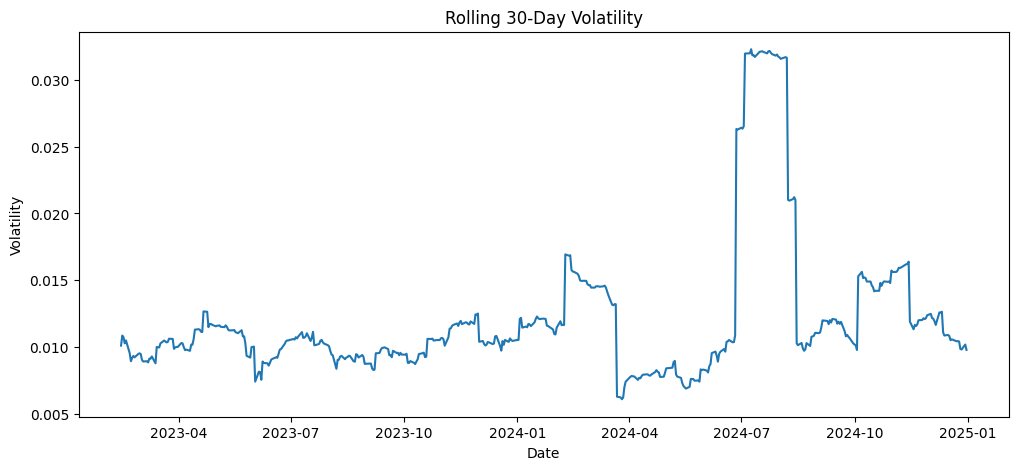

In [41]:
df["Volatility30"] = df["Close"].pct_change().rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(df.index, df["Volatility30"])

plt.title("Rolling 30-Day Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()
